In [1]:
# Imports & Setup
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Set device to GPU if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Load Data & Preprocess

Augment data to overcome lack of training images

Found classes: ['logos', 'nologos']
Total Images: 58
Training Set: 46
Validation Set: 12


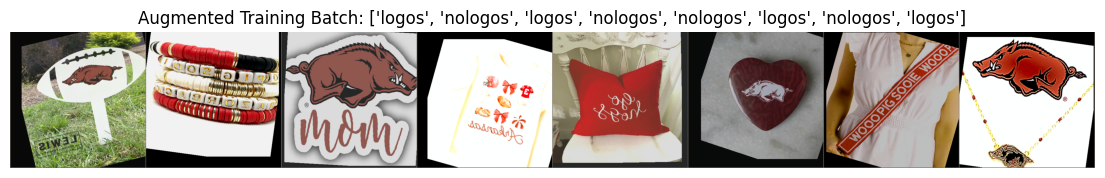

Enhanced data pipeline loaded.


In [2]:
# Data pipeline creates "new" images each epoch through augmentation
data_transform = transforms.Compose([
    # Fix PNG transparency
    transforms.Lambda(lambda x: x.convert("RGB")),
    
    # Geometry Augmentations

    # Randomly zooms in slightly and resizes to 500x500
    transforms.RandomResizedCrop(size=(500, 500), scale=(0.8, 1.0)),
    
    # Rotates +/- 20 degrees
    transforms.RandomRotation(degrees=20),
    
    # Mirrors the image
    transforms.RandomHorizontalFlip(p=0.5),
    
    # Shifts the image slightly so the logo isn't always center
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),

    # Changes brightness, contrast, and saturation
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05),

    # Convert to Tensor & Normalize
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

# Load data
data_dir = './pictures' 
try:
    full_dataset = datasets.ImageFolder(root=data_dir, transform=data_transform)
    class_names = full_dataset.classes
    print(f"Found classes: {class_names}")
except FileNotFoundError:
    print(f"Error: Directory '{data_dir}' not found")
    raise

# Split Data
total_count = len(full_dataset)
train_size = int(total_count * 0.8)
val_size = total_count - train_size

print(f"Total Images: {total_count}")
print(f"Training Set: {train_size}")
print(f"Validation Set: {val_size}")

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size],
                                          generator=torch.Generator().manual_seed(42))

# Create dataLoaders
BATCH_SIZE = 8
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Visualize the augmentation
# This checks if we are distorting the images too much
def show_augmented_batch(loader):
    images, labels = next(iter(loader))
    grid = make_grid(images)
    grid = grid.numpy().transpose((1, 2, 0))
    # Un-normalize for display
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    grid = std * grid + mean
    grid = np.clip(grid, 0, 1)
    
    plt.figure(figsize=(14, 6))
    plt.imshow(grid)
    plt.title(f"Augmented Training Batch: {[class_names[x] for x in labels]}")
    plt.axis('off')
    plt.show()

try:
    show_augmented_batch(train_loader)
    print("Enhanced data pipeline loaded.")
except Exception as e:
    print(f"Could not visualize batch: {e}")

CNN Architecture

In [3]:
class TunableCNN(nn.Module):
    def __init__(self, dropout_rate=0.5):
        super(TunableCNN, self).__init__()
        
        # Block 1: 3 -> 16 channels
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2, 2) # 500x500 -> 250x250
        
        # Block 2: 16 -> 32 channels
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2, 2) # 250x250 -> 125x125
        
        # Block 3: 32 -> 64 channels
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(2, 2) # 125x125 -> 62x62
        
        self.flatten = nn.Flatten()
        
        # Fully connected layer calculation
        # Final image size is 62x62 with 64 channels
        self.fc_input_size = 64 * 62 * 62 
        
        self.fc1 = nn.Linear(self.fc_input_size, 128)
        self.relu4 = nn.ReLU()
        
        # Dropout layer
        self.dropout = nn.Dropout(p=dropout_rate)
        
        # Output layer
        self.fc2 = nn.Linear(128, 2)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.pool3(self.relu3(self.conv3(x)))
        x = self.flatten(x)
        x = self.dropout(self.relu4(self.fc1(x)))
        x = self.fc2(x)
        return x

Training helper function

In [4]:
def train_candidate_model(config, train_loader, val_loader):
    print(f"\nStarting Training: {config['name']}")
    print(f"Params: LR={config['lr']}, Dropout={config['dropout']}, Epochs={config['epochs']}")
    
    # Initialize model & optimizer
    model = TunableCNN(dropout_rate=config['dropout']).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=config['lr'])
    
    # Training loop
    for epoch in range(config['epochs']):
        model.train()
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
    # Validation loop
    model.eval()
    all_preds = []
    all_labels = []
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    final_acc = 100 * correct / total
    print(f"Validation Accuracy: {final_acc:.2f}%")
    
    return {
        "name": config['name'],
        "model": model,
        "accuracy": final_acc,
        "predictions": all_preds,
        "true_labels": all_labels
    }

Experiment With Different Models

In [6]:
# Define 3 Candidate configurations to test
candidates = [
    {"name": "Model A (Baseline)", "lr": 0.001, "dropout": 0.5, "epochs": 20},
    {"name": "Model B (More Epochs)", "lr": 0.001, "dropout": 0.5, "epochs": 45},
    {"name": "Model C (High Dropout)", "lr": 0.001, "dropout": 0.7, "epochs": 45}
]

results = []

# Run the experiments
for config in candidates:
    res = train_candidate_model(config, train_loader, val_loader)
    results.append(res)

# Display comparison table
print("\n--- Experiment Results ---")
df = pd.DataFrame([{k: v for k, v in r.items() if k not in ['model', 'predictions', 'true_labels']} for r in results])
print(df)


Starting Training: Model A (Baseline)
Params: LR=0.001, Dropout=0.5, Epochs=20
Validation Accuracy: 50.00%

Starting Training: Model B (More Epochs)
Params: LR=0.001, Dropout=0.5, Epochs=45
Validation Accuracy: 66.67%

Starting Training: Model C (High Dropout)
Params: LR=0.001, Dropout=0.7, Epochs=45
Validation Accuracy: 58.33%

--- Experiment Results ---
                     name   accuracy
0      Model A (Baseline)  50.000000
1   Model B (More Epochs)  66.666667
2  Model C (High Dropout)  58.333333


Evaluation & Saving


Best Candidate: Model B (More Epochs) (66.67%)


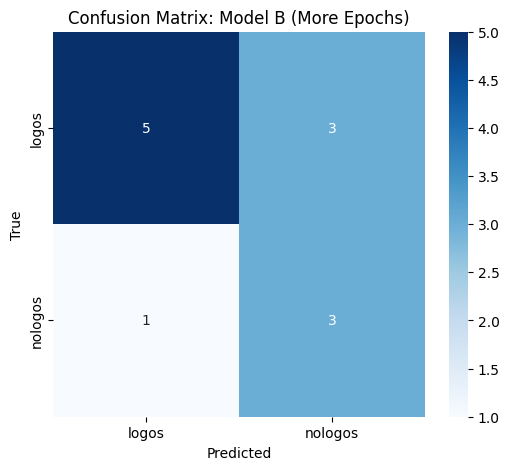


Detailed Classification Report:
              precision    recall  f1-score   support

       logos       0.83      0.62      0.71         8
     nologos       0.50      0.75      0.60         4

    accuracy                           0.67        12
   macro avg       0.67      0.69      0.66        12
weighted avg       0.72      0.67      0.68        12

Final Model saved to: Group_20_CNN_FullModel.ph


In [7]:
# Select best model
best_result = max(results, key=lambda x: x['accuracy'])
print(f"\nBest Candidate: {best_result['name']} ({best_result['accuracy']:.2f}%)")

# Confusion matrix
cm = confusion_matrix(best_result['true_labels'], best_result['predictions'])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix: {best_result["name"]}')
plt.show()

# Classification report
print("\nDetailed Classification Report:")
print(classification_report(best_result['true_labels'], best_result['predictions'], target_names=class_names))

# Save the best model
save_filename = f"Group_20_CNN_FullModel.ph"

torch.save(best_result['model'], save_filename)
print(f"Final Model saved to: {save_filename}")